# Which airports experience the highest, the lowest, and most consistent delay rates?

In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_AT = pd.read_excel("datasets/AirportTraffic.xlsx")
df_TIn = pd.read_excel("datasets/Taxi-In_Additional_Time.xlsx")
df_TOut = pd.read_excel("datasets/Taxi-Out_Additional_Time.xlsx")
df_AAD = pd.read_excel("datasets/AA_ATFM_Delay.xlsx")
df_AP = pd.read_excel("datasets/Airports_Punctuality.xlsx")
df_AID= pd.read_excel("datasets/Airport_IATA_delays_airline_reported.xlsx")
df_PDD = pd.read_excel("datasets/Primary_departure_Delay_Causes_AP.xlsx")
df_FPD = pd.read_excel("datasets/Flight_Punctuality_Distribution.xlsx")
df_Ageo = pd.read_csv("datasets/Airport_Geo2.csv", quoting=3, on_bad_lines="skip")

In [5]:
df_top20 = (
    df_AT.groupby("APT_ICAO")[["FLT_TOT_1", "FLT_DEP_1", "FLT_ARR_1"]] #Group by airport code
    .sum().sort_values(by="FLT_TOT_1",ascending=False) #Sum the values for each code of the 3 columns indicated
    .head(20).reset_index()) #Change "20" to change the number of airports analysed

# Adding airport's city name and state from original dataset
df_top20 = (df_top20.merge(df_AT[["APT_ICAO", "APT_NAME", "STATE_NAME", "YEAR", "MONTH_NUM"]]
                           .drop_duplicates(), on="APT_ICAO", how="left"))

airports_code_list = df_top20["APT_ICAO"].tolist()

In [50]:
# The columns 'Total_Delay_Period' and 'Total_Flights_Period' are changed to numeric types to ensure calculationnns on the mean are possible.
df_AID_TOP20 = df_AID.copy()

df_AID_TOP20['Total_Delay_Period'] = pd.to_numeric(df_AID['Total_Delay_Period'], errors='coerce')
df_AID_TOP20['Total_Flights_Period'] = pd.to_numeric(df_AID['Total_Flights_Period'], errors='coerce')
df_AID_TOP20['TF'] = pd.to_numeric(df_AID['TF'], errors='coerce')

# Filter the delay dataset for only the top 20 airports
df_AID_TOP20 = df_AID[df_AID["APT_ICAO"].isin(airports_code_list)].copy()

# Calculate delay ratio as percentage
df_AID_TOP20["Delay_Ratio"] = (df_AID_TOP20["TF"] / df_AID_TOP20["Total_Flights_Period"]) * 100
df_AID_TOP20.head()


,Year_Lobt,Month_Lobt,APT_ICAO,Label,TD,TF,Total_Flights_Period,adm,Total_Delay_Period,pd,DateLabel,label2,Delay_Ratio
680,2023,April,EDDF,ATFM En-Rte Dem/Cap,7826,505,12448,0.628695,197451,3.963515,Apr23,ATFM En-Rte Dem/Cap,4.056877
681,2023,April,EDDF,ATFM Restrc at Dest Apt,5471,208,12448,0.439508,197451,2.770814,Apr23,ATFM Restrc at Dest Apt,1.670951
682,2023,April,EDDF,ATFM Staff/Equip En-Rte,7222,483,12448,0.580174,197451,3.657616,Apr23,ATFM Staff/Equip En-Rte,3.880141
683,2023,April,EDDF,ATFM Weather at Dest,981,43,12448,0.078808,197451,0.496832,Apr23,ATFM Weather at Dest,0.345437
684,2023,April,EDDF,Airc. and Ramp Handling,38690,2840,12448,3.108130,197451,19.594735,Apr23,Airc. and Ramp Handling,22.814910


To answer the research question, the delay rate per airport has to be calculated. The monthly delay rates are calculated.

A delay rate can be calculated based on the number of delayed flights or amount of delay minutes. Below, a code is implemented to create a dataframe where each row indicates statistics for one airport in one month. It shows both the delay rates based on the number as flights as the amount of delay minutes.

In [ ]:
# Duplicates are dropped and only rows with Total_Flights_Period > 0 are kept
df_month = df_AID_TOP20[df_AID_TOP20['Total_Flights_Period'] > 0].copy()

# The TF (delayed flights) column is summed to get the total number of delayed flights per month.
# The Total_Flights_Period and Total_Delay_Period are already unique monthly totals in the dataset. So, one value is selected by 'first' (this is representative for the entire month)
df_monthly_summary = (
    df_month.groupby(["APT_ICAO", "Year_Lobt", "Month_Lobt"])
    .agg(
        Total_Delayed_Flights_Month=("TF", "sum"),
        Total_Flights_Period=("Total_Flights_Period", "first"),  
        Total_Delay_Period_Minutes=("Total_Delay_Period", "first")
    )
    .reset_index()
)

# Filter rows in which the  'Total_Flights_Period' is 0 or NaN )
# df_monthly_summary = df_monthly_summary[df_monthly_summary['Total_Flights_Period'].notna() & 
#                                         (df_monthly_summary['Total_Flights_Period'] > 0)].copy()

# Calculate monthly delay rate based on the number of delayed flights (as percentage)
df_monthly_summary.loc[:, 'Monthly_Delay_Rate_Number_of_flights'] = (
    df_monthly_summary['Total_Delayed_Flights_Month'] / df_monthly_summary['Total_Flights_Period'] * 100)

# Calculate monthly delay rate based on the amount of delay minutes
df_monthly_summary.loc[:, 'Monthly_Delay_Rate_Number_of_delay_minutes'] = (
    df_monthly_summary['Total_Delay_Period_Minutes'] / df_monthly_summary['Total_Flights_Period'])

# To create a 'yyyy-mm' column, map the month names to numbers and create a column 
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_monthly_summary['Month_Num'] = df_monthly_summary['Month_Lobt'].map(month_map)

df_monthly_summary['YEAR_MONTH'] = df_monthly_summary['Year_Lobt'].astype(str) + '-' + \
                                   df_monthly_summary['Month_Num'].astype(str).str.zfill(2)

# The columns to show in the dataframe
df_monthly_means = df_monthly_summary[[
    "APT_ICAO",
    "YEAR_MONTH",
    "Monthly_Delay_Rate_Number_of_flights",
    "Monthly_Delay_Rate_Number_of_delay_minutes",
    "Total_Delayed_Flights_Month",
    "Total_Delay_Period_Minutes",
    "Total_Flights_Period",
]].sort_values(by=["APT_ICAO", "YEAR_MONTH"])

# Print de eerste rijen van de uiteindelijke tabel
print(df_monthly_means)

# Delay Rate Analysis

Now we analyse the delay rate of each airport to determine a reasonable delay threshold to use in the prediction model. In the aviation industry, 98% is considered to be a good reference point in this kind on analysis. Let's see if this still applies to our data.

In [ ]:
dra = df_monthly_means[["APT_ICAO", "YEAR_MONTH", "Monthly_Delay_Rate_Number_of_flights"]]
dra["Year"] = (dra["YEAR_MONTH"]).str.split("-").str[0].astype(int)
dra["YEAR_MONTH"] = (dra["YEAR_MONTH"]).str.split("-").str[1].astype(int)
dra.rename(columns={"YEAR_MONTH": "Month", "Monthly_Delay_Rate_Number_of_flights": "DR"}, inplace=True)
dra = dra[["APT_ICAO", "Year", "Month", "DR"]] 

The following plot shows the delay rate trend for each airport in 2023 and 2024 separately. The horizontal dashed line represent the 98% threshold: this was chosen because it can reasonably split the dataset and it's a common delay ratio reference value used in the aviation industry.

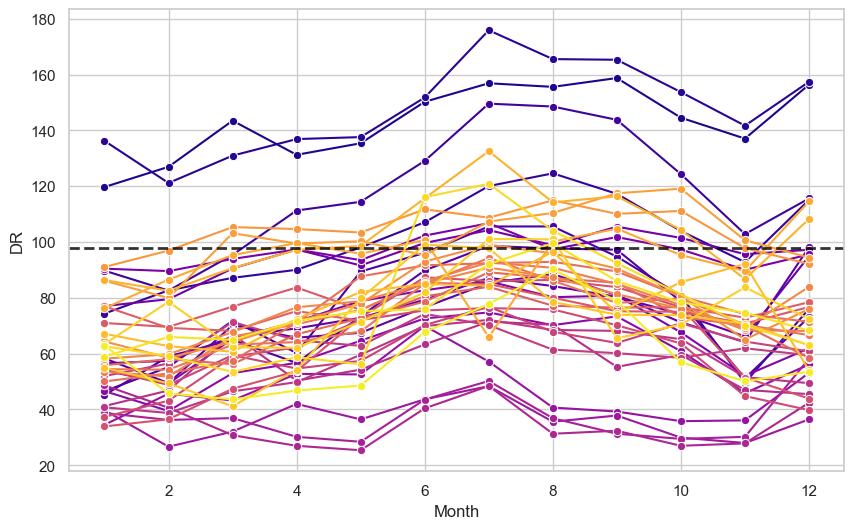

In [ ]:
plt.figure(figsize=(10,6))
# Create a combined label for each airport-year pair (we could also just use the code and merge the years)
dra["Airport_Year"] = dra["APT_ICAO"].astype(str) + " - " + dra["Year"].astype(str)
# Plot
sns.lineplot(
    data=dra,
    x="Month",
    y="DR",
    hue="Airport_Year",
    palette="plasma",
    marker="o",
    legend=False
)
plt.axhline(y=98, color = "black", linestyle='--', linewidth=2, alpha=0.8, label='98% threshold')

This plot shows the delay ratio trends in 2023 and 2024 and we can see that only a small portion of the curve is 98% threshold, which is exactly what we wanted and expected

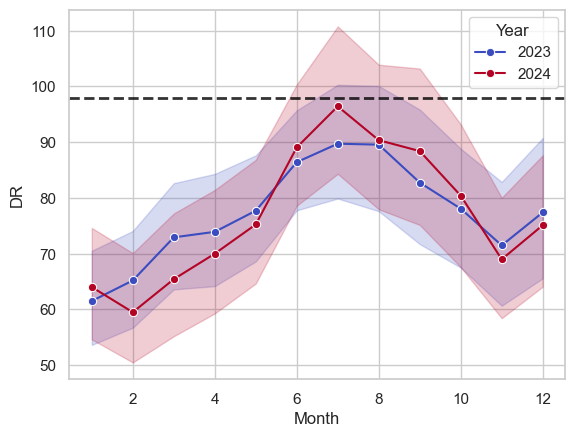

In [87]:
# Plot
sns.lineplot(
    data=dra,
    x="Month",
    y="DR",
    hue="Year",
    palette="coolwarm",
    marker="o",
    legend=True
)
plt.axhline(y=98, color = "black", linestyle='--', linewidth=2, alpha=0.8, label='98% threshold')

# Delay Rate & Coefficient of Variation Analysis

To show which airports face the most consistent delay rates, a Coefficient of Variation (CV), which measures consistency, is calculated. The calculation is standard deviation divid by mean and based on the mean amount of delayed minutes (i.e. the Monthly_Delay_Rate_Number_of_delay_minutes variable).

The choice for the delay rate based on minutes is made as this shows the duration of flight delays. This in contrast to the delay rate by number of flights, which treats a short delay the same as a very long delay. Therefore, the overall operational performance of airports can be better calculated based on the minutes. 

The lower the CV, the more consistent the delay rates are.
print(df_with_monthly_delay_rates)
df_with_monthly_delay_rates.to_csv("datasets_rq4/df_with_monthly_delay_rates.csv")

In [ ]:
consistency = (
    df_monthly_summary.groupby("APT_ICAO")["Monthly_Delay_Rate_Number_of_delay_minutes"] 
    .agg(["mean", "std"])
    .reset_index()
)

# Calculate the delay rate coefficient (the CV: Coefficient of Variation) as:
consistency["cv"] = consistency["std"] / consistency["mean"]  # Standard deviation divided by mean. The lower the CV, the more consistent the delay rates are.
consistency = consistency.sort_values("cv")

# Airports are sorted by their consistency (cv), to use this in boxplots later on.
airports_sorted_by_consistency = consistency["APT_ICAO"].values

# Print de eerste rijen van de uiteindelijke tabellen (zowel de maandelijkse samenvatting als de consistentie)
print("df_monthly_means")
print(df_monthly_means.head())

print("\nConsistency of delay rates per airport:")
print(consistency.head())

print("\nSorted airports by consistency (cv):")
print(airports_sorted_by_consistency)

To investigate yearly trends, the mean and standard deviation of the monthly total delay minutes (Total_Delay_Period_Minutes) are calculated for each airport for the years 2023 and 2024.
This provides an overview of the average monthly amount of delay minutes per year and the variability of this amount (indicated with the standard deviation).


In [ ]:
df_monthly_summary['YEAR'] = df_monthly_summary['Year_Lobt']

# Calculate the mean and standard deviation of the monthly delay rates per airport per year.
yearly_stats = (
    df_monthly_summary.groupby(["APT_ICAO", "YEAR"]) 
    .agg(
        # Calculate mean and standard deviation of Monthly Delay Rate based on delay minutes
        Mean_monthly_delay_minutes=("Total_Delay_Period_Minutes", "mean"),
        Std_monthly_delay_minutes=("Total_Delay_Period_Minutes", "std"),
    )
    .reset_index()
)

# Create separate dataframes for 2023 and 2024
# Zorg ervoor dat deze jaren in uw dataset bestaan
mean_std_23 = yearly_stats[yearly_stats["YEAR"] == 2023].copy()
mean_std_24 = yearly_stats[yearly_stats["YEAR"] == 2024].copy()

print(mean_std_23)
print(mean_std_24)


Finally, to answer the research question a figure is shown with the mean monthly delay rate and the CV value for each airport and each year (2023 and 2024). This allows us to see the lowest and highest average monthly delay rate and consistency in monthly delay rate. The consistency is indicated by the coefficient value (CV) that is calculated earlier.

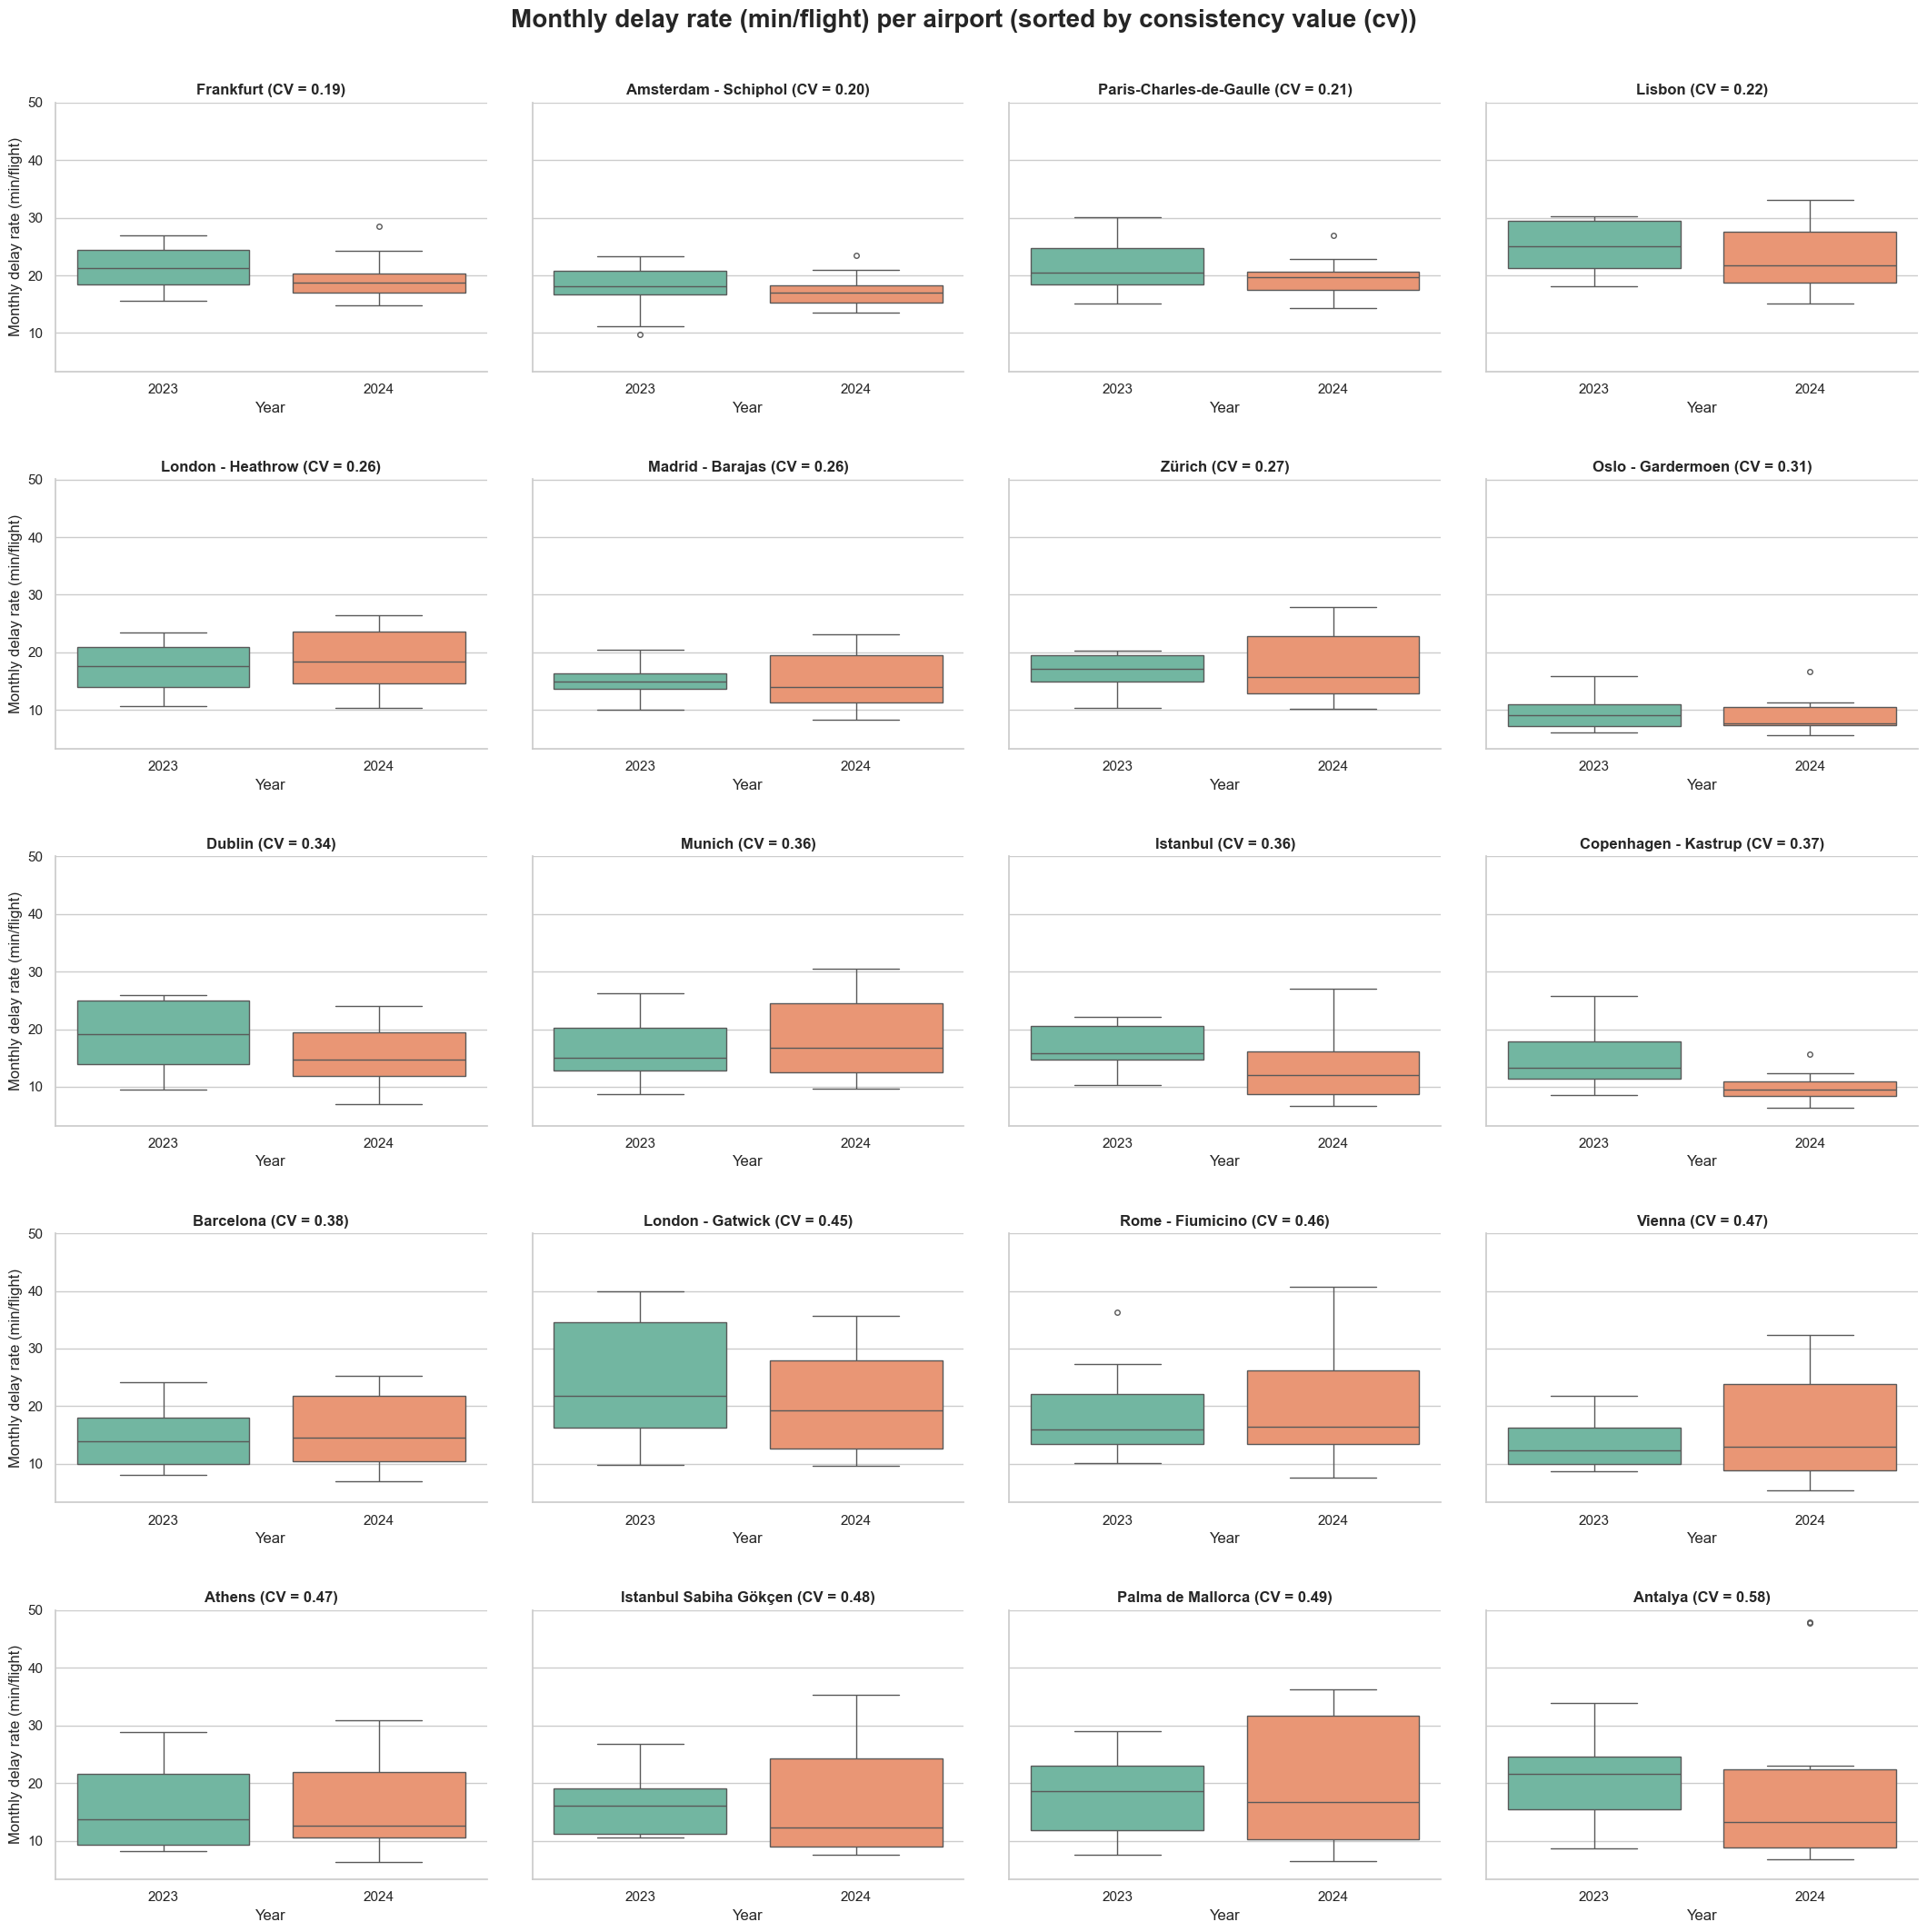

In [88]:
sns.set_theme(style="whitegrid", palette="Set2")

# To add names on top of subplots instead of ICAO codes, create a dictionary mapping ICAO codes to airport names. The airport names are taken from the df_AAD dataset as those are not shown in the df_AID. 
airport_names_dict = (
    df_AAD[['APT_ICAO', 'APT_NAME']]
    .drop_duplicates()
    .set_index('APT_ICAO')['APT_NAME']
    .to_dict()
)

# Create subplots with 5 rows and 4 columns, whereby each subplot represents an airport.
fig, axes = plt.subplots(
    nrows=5, 
    ncols=4, 
    figsize=(22, 22), 
    sharey=True
)

axes = axes.flatten()

# Create boxplots for each airport based on their consistency
for i, airport_icao in enumerate(airports_sorted_by_consistency):
    ax = axes[i]
    # Filter data for the specific airport and get its CV value
    data = df_monthly_summary[df_monthly_summary["APT_ICAO"] == airport_icao]
    cv = consistency.loc[consistency["APT_ICAO"] == airport_icao, "cv"].iloc[0]
    
    # The airport name is retrieved from the dictionary created earlier
    airport_name = airport_names_dict.get(airport_icao, airport_icao)

    sns.boxplot(
        data=data,
        x="Year_Lobt",
        y="Monthly_Delay_Rate_Number_of_delay_minutes",
        hue="Year_Lobt",
        ax=ax,
        palette="Set2",
        fliersize=4,
        legend=False
    )

    # On top of each subplot, the airport name and its CV value are shown. On the x-asis, the years are shown and on the y-axis, the monthly delay rate in minutes per flight.
    ax.set_title(f"{airport_name} (CV = {cv:.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("Monthly delay rate (min/flight)")


fig.suptitle("Monthly delay rate (min/flight) per airport (sorted by consistency value (cv))", fontsize=20, fontweight='bold')

# The figure layout is adjusted 
fig.tight_layout(pad=3)
sns.despine()

plt.show()


To conclude, based on the calculated and plotted monthly delay rates (based on the amount of delay minutes):

Oslo - Gardermoen experiences the lowest monthly delay rate in 2023 and 2024 out of the twenty busiest airports in Europe. This can be seen in the figure above: the mean delay rate is the lowest out of the examined airports (i.e. below 10 min/flight).

Lisbon faces, on average, the highest delay rates. 

Frankfurt has the most consistent delay rates as the coefficient value is the lowest (CV = 0.19) out of all airports. So, Frankfurt has the most stable delay rates from the twenty busiest airports in Europe. On the contrary, the highest coefficient value (CV = 0.58) is indicated for Antalya. This means Antalya faces the most volatile delay rates. I.e.: the consistency of delay rates is the lowest at Antalya airport.